In [27]:
import sys 
sys.path.append('/home/royhirsch/conformal/')

from conformal import get_conformal_module
from evaluate import load_pickle, split_data
from conf_tools import get_logits_dataloader, platt_logits
from scipy.special import softmax 
import numpy as np

file_name = '/home/royhirsch/conformal/data/embeds_n_logits/aug/medmnist/tissuemnist_test.pickle'
conformal_module_name = 'aps'
t = 1.
alpha = 0.1

data = load_pickle(file_name)
ds = split_data(data, seed=42)
train_data, val_data = ds['train'], ds['test']

print('Train/Calib shape: {} | Val shape: {}'.format(train_data['labels'].shape,
                                                        val_data['labels'].shape))
conformal = get_conformal_module(conformal_module_name)

# mets = conformal.baseline_calibrate(train_data['preds'], train_data['labels'],
#                                     val_data['preds'], val_data['labels'])
# print(mets)

train_dataloader = get_logits_dataloader(train_data['preds'],
                                            train_data['labels'])
t = platt_logits(train_dataloader)
t = 1

train_data['probs'] = softmax(train_data['preds'] / t, 1)
val_data['probs'] = softmax(val_data['preds'] / t, 1)

scores = conformal.get_scores(train_data['probs'], train_data['labels'])
n = len(scores)
qhat = np.quantile(
    scores, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)

val_scores = conformal.get_scores(val_data['probs'], val_data['labels'])
sets = conformal.get_sets(np.full_like(val_scores, qhat), val_data['probs'])


Train/Calib shape: (40188,) | Val shape: (7092,)


  2%|▏         | 2/100 [00:01<01:32,  1.06it/s]
/tmp/ipykernel_95038/2075477217.py:37: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  qhat = np.quantile(


In [20]:
n = 2
sets[n], prediction_sets[n]

((6,), array([ True,  True, False, False, False, False,  True,  True]))

(array([ 517.,  520., 1038.,    0., 1700.,  998.,    0., 1029.,  781.,
         509.]),
 array([0. , 0.7, 1.4, 2.1, 2.8, 3.5, 4.2, 4.9, 5.6, 6.3, 7. ]),
 <BarContainer object of 10 artists>)

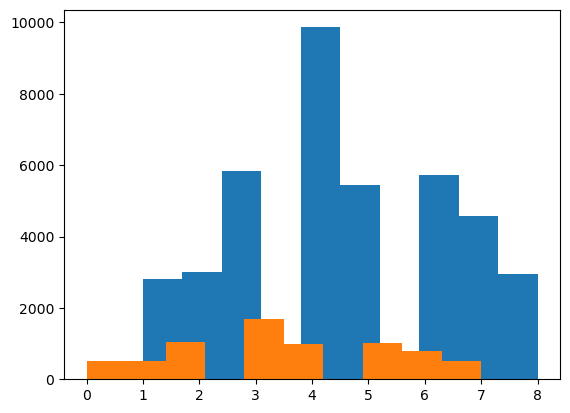

In [22]:
l1 = [len(s) for s in sets]
l2 = [sum(s) for s in prediction_sets]
plt.hist(l1)
plt.hist(l2)

(array([   34.,   322.,   941.,  1765.,  2310.,  2775.,  3381.,  4347.,
         6759., 17554.]),
 array([0.17588319, 0.25829488, 0.34070659, 0.42311826, 0.50552994,
        0.58794165, 0.67035335, 0.75276506, 0.83517671, 0.91758841,
        1.00000012]),
 <BarContainer object of 10 artists>)

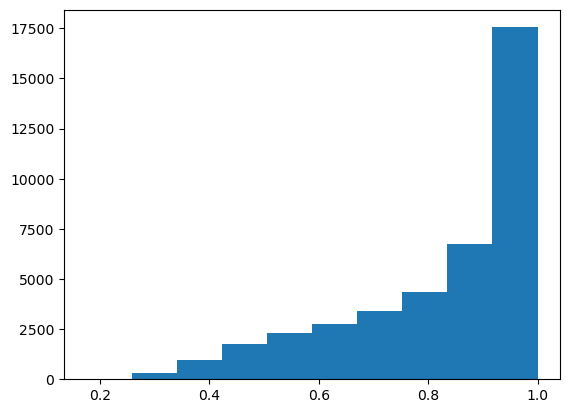

In [2]:
import matplotlib.pyplot as plt
plt.hist(scores)

/tmp/ipykernel_95038/940147523.py:10: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  qhat = np.quantile(


(array([   34.,   322.,   941.,  1765.,  2310.,  2775.,  3381.,  4347.,
         6759., 17554.]),
 array([0.17588319, 0.25829488, 0.34070659, 0.42311826, 0.50552994,
        0.58794165, 0.67035335, 0.75276506, 0.83517671, 0.91758841,
        1.00000012]),
 <BarContainer object of 10 artists>)

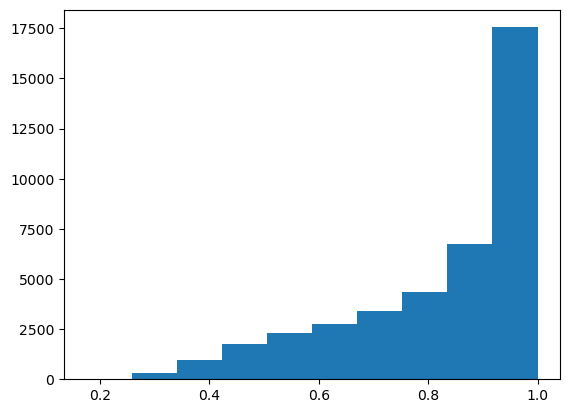

In [26]:
import numpy as np

n = len(train_data['probs'])
cal_pi = train_data['probs'].argsort(1)[:, ::-1]
cal_srt = np.take_along_axis(train_data['probs'], cal_pi, axis=1).cumsum(axis=1)
cal_scores = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[
    range(n), train_data['labels']
]
# Get the score quantile
qhat = np.quantile(
    cal_scores, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)
# Deploy (output=list of length n, each element is tensor of classes)
val_pi = val_data['probs'].argsort(1)[:, ::-1]
val_srt = np.take_along_axis(val_data['probs'], val_pi, axis=1).cumsum(axis=1)
prediction_sets = np.take_along_axis(val_srt <= qhat, val_pi.argsort(axis=1), axis=1)
# prediction_sets = np.take_along_axis(val_srt <= np.full_like(val_data['probs'], qhat), val_pi.argsort(axis=1), axis=1)

plt.hist(cal_scores)


In [28]:
# Get scores. calib_X.shape[0] == calib_Y.shape[0] == n
cal_pi = train_data['probs'].argsort(1)[:, ::-1]
cal_srt = np.take_along_axis(train_data['probs'], cal_pi, axis=1).cumsum(axis=1)
cal_softmax_correct_class = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[
range(n), train_data['labels']
]

cumsum_index = []
for row, val in zip(cal_softmax_correct_class, cal_srt):
    cumsum_index.append(np.where(row == val)[0][0])
cumsum_index = np.asarray(cumsum_index)

# cumsum_index = np.where(cal_srt == cal_softmax_correct_class[:,None])[1]

high = cal_softmax_correct_class
low = np.zeros_like(high)
low[cumsum_index != 0] = cal_srt[np.where(cumsum_index != 0)[0], cumsum_index[cumsum_index != 0]-1]
cal_scores = np.random.uniform(low=low, high=high)

# Get the score quantile
qhat = np.quantile(
    cal_scores, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)
# Deploy (output=list of length n, each element is tensor of classes)
val_pi = val_data['probs'].argsort(1)[:, ::-1]
val_srt = np.take_along_axis(val_data['probs'], val_pi, axis=1).cumsum(axis=1)


n_val = val_srt.shape[0]
cumsum_index = np.sum(val_srt <= qhat, axis=1) # [n, c]
high = val_srt[np.arange(n_val), cumsum_index] # [n,]
low = np.zeros_like(high)
# for low values take a smallest set
low[cumsum_index > 0] = val_srt[np.arange(n_val), cumsum_index-1][cumsum_index > 0]
prob = (qhat - low)/(high - low)
rv = np.random.binomial(1,prob,size=(n_val))
randomized_threshold = low
randomized_threshold[rv == 1] = high[rv == 1]
randomized_threshold = np.maximum(randomized_threshold, val_srt[:,0])
prediction_sets = np.take_along_axis(val_srt <= randomized_threshold[:,None], val_pi.argsort(axis=1), axis=1)



/tmp/ipykernel_95038/1727907800.py:21: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  qhat = np.quantile(


In [32]:
high.shape

(7092,)

In [9]:
n = 3
# print(val_data['probs'][n])
print('')
print(low[n], high[n], val_data['probs'][n][val_data['labels'][n]])


0.9880374 0.9880374 0.5167682


In [51]:
np.sort(train_data['probs'][n])[::-1]

array([7.3548883e-01, 1.4295472e-01, 5.4126218e-02, 4.1688886e-02,
       2.0000832e-02, 5.6063249e-03, 1.2028259e-04, 1.3925180e-05],
      dtype=float32)

In [53]:
p = train_data['probs'][n]
true_p = train_data['probs'][n][train_data['labels'][n]]
sum(p[p>=true_p])

0.9742586575448513